In [1]:
import pandas as pd
import numpy as np
import pywt
from scipy.stats import median_absolute_deviation
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy import stats
from tsfresh import extract_features as ef
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute
import os
from tsfresh.feature_extraction import EfficientFCParameters, MinimalFCParameters
from tsfresh.feature_selection.relevance import calculate_relevance_table

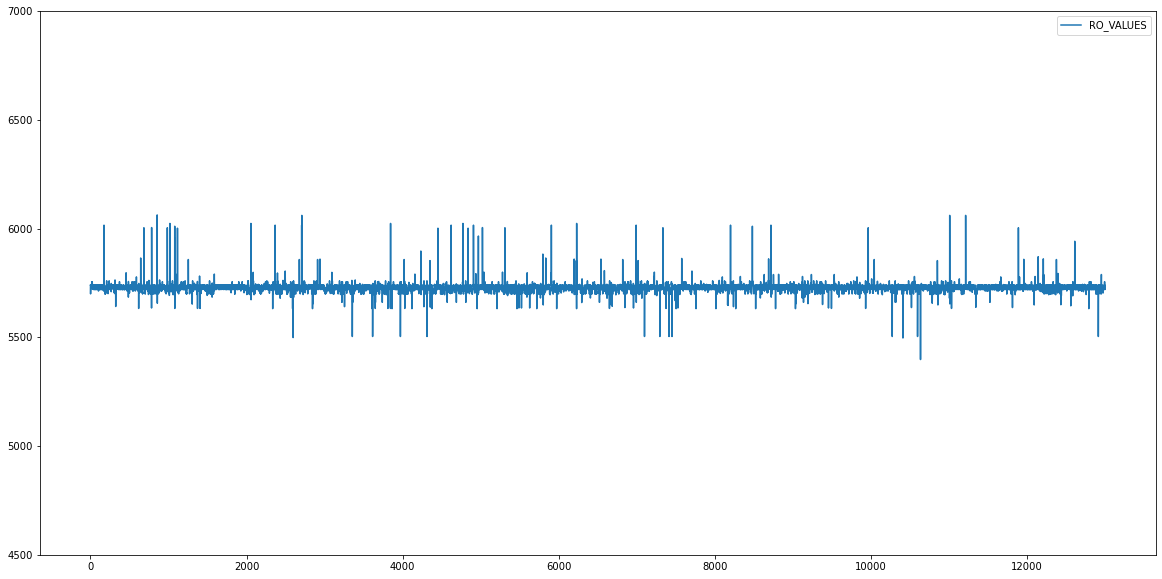

In [31]:
csv_file = '../ro_uart_logs/working/resnet18_no_el_12m_334_non_block_sv.csv'

# Read the CSV file into a Pandas DataFrame
df = pd.read_csv(csv_file)
df = df.iloc[15000:28000]
z_scores = stats.zscore(df['RO_VALUES'])
threshold =20

df = df[(np.abs(z_scores) <= threshold)]
df.reset_index(drop=True, inplace=True)

df.plot(subplots=True, figsize=(20,10))
plt.ylim(4500,7000)
plt.show()

In [32]:
def extract_features(windows, only_stat=False):
    
    features = ef(windows, column_id='id', column_sort='time', n_jobs=6, default_fc_parameters=EfficientFCParameters())
    features = impute(features)
    return features

    
    
    

In [ ]:
window_size = 150
stride = 1

windows = [df.iloc[i:i+window_size] for i in range(0, len(df)-window_size+1, stride)]
data = []
for i, window in enumerate(windows):
    window['id'] = i
    window['time'] = range(len(window))
    data.append(window)

    
final_df = pd.concat(data, ignore_index=True)  

features_df = extract_features(final_df)

/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

...

/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['time'] = range(len(window))
/tmp/ipykernel_83260/1363571685.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window['id'] = i
/tmp/ipykernel_83260/1363571685.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

Feature Extraction:   0%|                                | 0/30 [00:00<?, ?it/s]

In [22]:
features_df

,RO_VALUES__variance_larger_than_standard_deviation,RO_VALUES__has_duplicate_max,RO_VALUES__has_duplicate_min,RO_VALUES__has_duplicate,RO_VALUES__sum_values,RO_VALUES__abs_energy,RO_VALUES__mean_abs_change,RO_VALUES__mean_change,RO_VALUES__mean_second_derivative_central,RO_VALUES__median,...,RO_VALUES__permutation_entropy__dimension_6__tau_1,RO_VALUES__permutation_entropy__dimension_7__tau_1,RO_VALUES__query_similarity_count__query_None__threshold_0.0,"RO_VALUES__matrix_profile__feature_""min""__threshold_0.98","RO_VALUES__matrix_profile__feature_""max""__threshold_0.98","RO_VALUES__matrix_profile__feature_""mean""__threshold_0.98","RO_VALUES__matrix_profile__feature_""median""__threshold_0.98","RO_VALUES__matrix_profile__feature_""25""__threshold_0.98","RO_VALUES__matrix_profile__feature_""75""__threshold_0.98",RO_VALUES__mean_n_absolute_max__number_of_maxima_7
0,1.0,0.0,0.0,1.0,860045.0,4.931195e+09,7.100671,0.000000,0.000000,5740.0,...,4.077539,4.560089,0.0,0.892672,3.387053,2.352161,2.586768,1.980144,2.745833,5744.571429
1,1.0,0.0,0.0,1.0,860025.0,4.930965e+09,7.234899,-0.134228,0.067568,5740.0,...,4.077539,4.575710,0.0,0.892672,3.387053,2.351988,2.586768,1.980144,2.738345,5744.571429
2,1.0,0.0,0.0,1.0,860007.0,4.930759e+09,6.979866,0.147651,-0.128378,5740.0,...,4.080082,4.581703,0.0,0.892672,3.387053,2.351686,2.586768,1.980144,2.738345,5744.571429
3,1.0,0.0,0.0,1.0,860027.0,4.930988e+09,6.724832,-0.134228,-0.006757,5740.0,...,4.102502,4.581703,0.0,0.892672,3.387053,2.341655,2.569847,1.953869,2.730684,5744.571429
4,1.0,0.0,0.0,1.0,860007.0,4.930758e+09,6.724832,-0.134228,0.000000,5740.0,...,4.124153,4.581703,0.0,0.892672,3.387053,2.320652,2.531763,1.902833,2.730684,5744.571429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12811,1.0,0.0,0.0,1.0,859011.0,4.919404e+09,12.449664,-0.006711,-0.118243,5724.0,...,4.502123,4.775998,0.0,0.700488,2.782484,2.025048,2.078722,1.839962,2.282295,5749.285714
12812,1.0,0.0,0.0,1.0,859027.0,4.919587e+09,12.557047,0.114094,0.043919,5724.0,...,4.502123,4.775998,0.0,0.700488,2.782484,2.020854,2.078722,1.839962,2.282295,5749.285714
12813,1.0,0.0,0.0,1.0,859027.0,4.919587e+09,12.644295,-0.026846,-0.101351,5724.0,...,4.502123,4.775998,0.0,0.700488,2.782484,2.025295,2.078722,1.839962,2.282295,5749.285714
12814,1.0,0.0,0.0,1.0,859043.0,4.919770e+09,12.691275,0.020134,0.121622,5724.0,...,4.502123,4.775998,0.0,0.700488,2.831934,2.031079,2.078722,1.839962,2.287347,5749.285714


In [23]:
num_clusters = 2
kmeans = KMeans(n_clusters=num_clusters)
cluster_labels = kmeans.fit_predict(features_df)

/home/srchand/anaconda3/envs/tvm-build-il-2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


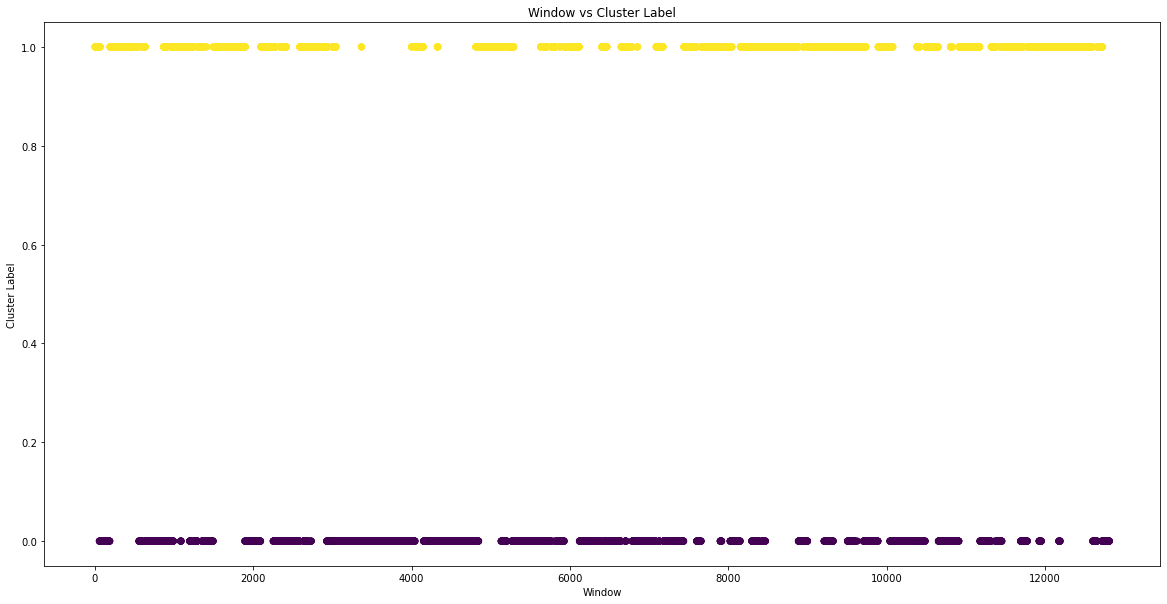

In [24]:
plt.figure(figsize=(20, 10))
plt.scatter(range(len(cluster_labels)), cluster_labels, c=cluster_labels, cmap='viridis')
plt.xlabel('Window')
plt.ylabel('Cluster Label')
plt.title('Window vs Cluster Label')
plt.show()

In [28]:
inner_window_size = 125
predictions = []
for i in range(len(cluster_labels) - inner_window_size + 1):
    window_cluster_labels = cluster_labels[i:i + inner_window_size]
    majority_class = max(set(window_cluster_labels), key=window_cluster_labels.tolist().count)

    # Step 6: Label items in the sliding window
    predictions.extend([majority_class])

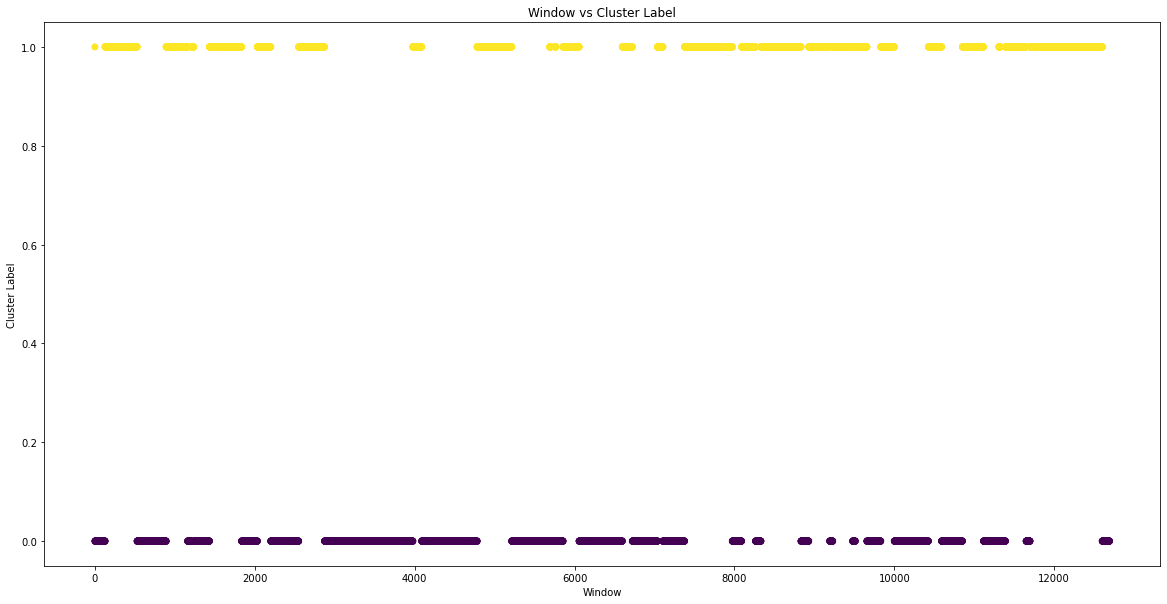

In [29]:
plt.figure(figsize=(20, 10))
plt.scatter(range(len(predictions)), predictions, c=predictions, cmap='viridis')
plt.xlabel('Window')
plt.ylabel('Cluster Label')
plt.title('Window vs Cluster Label')
plt.show()